In [1]:
import eos

In [2]:
eos.Parameters()['decay-constant::B_d']

$$f_{\bar{B}^0}$$,(eos.Parameter)
current value,0.1905
default value,0.1905


In [3]:
EOS_BASE_DIRECTORY='./predictions-base-K0mumu'

In [4]:
eos.tasks.sample_prior('./predictions_K0mumu.yaml','SM',base_directory=EOS_BASE_DIRECTORY,N=2000,seed=42)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/SM/samples',))

In [5]:
output = eos.data.ImportanceSamples(EOS_BASE_DIRECTORY + '/data/SM/samples')
display(output.samples.shape)

(2000, 1)

In [8]:
eos.tasks.predict_observables('./predictions_K0mumu.yaml','SM','B0-to-K0-mu-mu',base_directory=EOS_BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/SM/pred-B0-to-K0-m…

In [9]:
!tree ./predictions-base

./predictions-base
└── data
    ├── FF-LQCD-SSE
    │   ├── nested
    │   │   ├── description.yaml
    │   │   ├── dynesty_results.npy
    │   │   └── log
    │   ├── pred-B-to-K-mu-mu-highq2-binned
    │   │   ├── description.yaml
    │   │   ├── log
    │   │   ├── samples.npy
    │   │   └── weights.npy
    │   ├── pred-B-to-K-mu-mu-lowq2
    │   │   ├── description.yaml
    │   │   ├── log
    │   │   ├── samples.npy
    │   │   └── weights.npy
    │   ├── pred-B-to-K-mu-mu-lowq2-binned
    │   │   ├── description.yaml
    │   │   ├── log
    │   │   ├── samples.npy
    │   │   └── weights.npy
    │   └── samples
    │       ├── description.yaml
    │       ├── posterior_values.npy
    │       ├── samples.npy
    │       └── weights.npy
    └── SM
        ├── pred-Bplus-to-Kplus-mu-mu
        │   ├── description.yaml
        │   ├── log
        │   ├── samples.npy
        │   └── weights.npy
        └── samples
            ├── description.yaml
            ├── log
            ├── s

In [10]:
import numpy as np
prediction = eos.data.Prediction(EOS_BASE_DIRECTORY + '/data/SM/pred-B0-to-K0-mu-mu')
avg = np.average(prediction.samples[:, 0], weights=prediction.weights, axis=0)
std = np.sqrt(np.average((prediction.samples[:, 0] - avg)**2, weights=prediction.weights, axis=0))
print(f'BR(B_d->K0MuMu) = {100 * avg:.9f} +/- {100 * std:.9f} %')

BR(B_d->K0MuMu) = 0.000002937 +/- 0.000000001 %


In [11]:
eos.tasks.sample_nested('predictions_K0mumu.yaml', 'FF-LQCD-SSE', base_directory=EOS_BASE_DIRECTORY, nlive=250, dlogz=0.5, seed=42)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-LQCD-SSE/nested…

In [12]:
!tree -L 2 ./predictions-base

./predictions-base
└── data
    ├── FF-LQCD-SSE
    └── SM

3 directories, 0 files


In [13]:
eos.tasks.predict_observables('predictions_K0mumu.yaml', 'FF-LQCD-SSE', 'B0-to-K0-mu-mu-lowq2',  base_directory=EOS_BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-LQCD-SSE/pred-B…

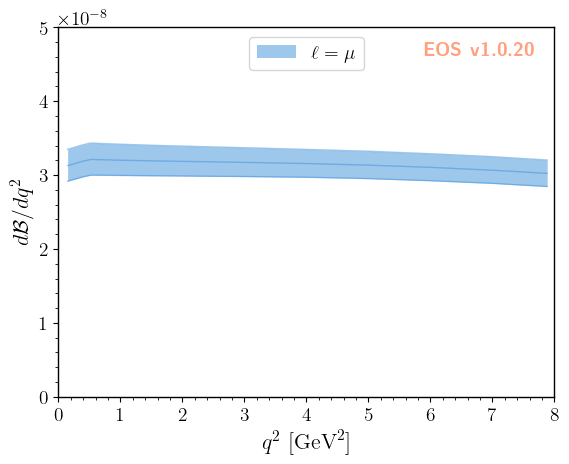

In [15]:
figure_args = """
plot:
  xaxis: { label: '$q^2$', unit: '$\\textnormal{GeV}^2$', range: [0.0, 8] }
  yaxis: { label: '$d\\mathcal{B}/dq^2$',                 range: [0.0,  5e-8] }
  legend: { position: 'upper center' }
  items:
    - { type: 'uncertainty', label: '$\\ell=\\mu$',
        variable: 'q2', range: [0.00, 8.0],
        datafile: './predictions-base-K0mumu/data/FF-LQCD-SSE/pred-B0-to-K0-mu-mu-lowq2'
      }
"""
figure = eos.figure.FigureFactory.from_yaml(figure_args)
figure.draw()

In [16]:
eos.tasks.predict_observables('predictions_K0mumu.yaml', 'FF-LQCD-SSE', 'B0-to-K0-mu-mu-lowq2-binned',  base_directory=EOS_BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-LQCD-SSE/pred-B…

In [17]:
eos.tasks.predict_observables('predictions_K0mumu.yaml', 'FF-LQCD-SSE', 'B0-to-K0-mu-mu-highq2-binned',  base_directory=EOS_BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-LQCD-SSE/pred-B…

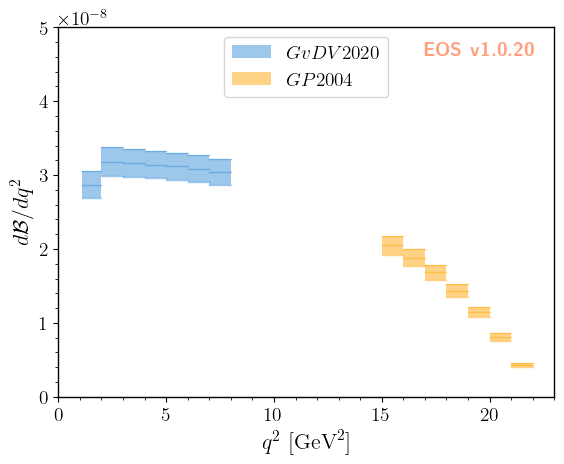

In [18]:
figure_args = """
plot:
  xaxis: { label: '$q^2$', unit: '$\\textnormal{GeV}^2$', range: [0.0, 23] }
  yaxis: { label: '$d\\mathcal{B}/dq^2$',                 range: [0.0,  5e-8] }
  legend: { position: 'upper center' }
  items:
    - { type: 'uncertainty-binned', label: '$GvDV2020$',
        variable: 'q2', range: [0.00, 23.0],
        datafile: './predictions-base-K0mumu/data/FF-LQCD-SSE/pred-B0-to-K0-mu-mu-lowq2-binned'
      }
    - { type: 'uncertainty-binned', label: '$GP2004$',
        variable: 'q2', range: [0.00, 23.0],
        datafile: './predictions-base-K0mumu/data/FF-LQCD-SSE/pred-B0-to-K0-mu-mu-highq2-binned'
      }      
"""
figure = eos.figure.FigureFactory.from_yaml(figure_args)
figure.draw()

import matplotlib.pyplot as plt
fig = plt.gcf()
fig.savefig('B0_to_K0_mumu.png', bbox_inches='tight')

In [19]:
import os

print(os.listdir('./predictions-base-K0mumu/data/FF-LQCD-SSE/pred-B0-to-K0-mu-mu-lowq2-binned'))

['weights.npy', 'description.yaml', 'samples.npy', 'log']


In [20]:
print(os.listdir('./predictions-base-K0mumu/data/FF-LQCD-SSE/pred-B0-to-K0-mu-mu-highq2-binned'))

['weights.npy', 'description.yaml', 'samples.npy', 'log']


In [21]:
import numpy as np
import pandas as pd
import yaml

def prediction_table(path, bins):
    samples = np.load(f"{path}/samples.npy")   # shape: (N samples, N observables)
    weights = np.load(f"{path}/weights.npy")

    # normalize weights
    weights = weights / np.sum(weights)

    rows = []
    for i, (q2_min, q2_max) in enumerate(bins):
        x = samples[:, i]

        central = np.average(x, weights=weights)
        variance = np.average((x - central)**2, weights=weights)
        sigma = np.sqrt(variance)

        rows.append({
            "q2_min": q2_min,
            "q2_max": q2_max,
            "q2_center": 0.5 * (q2_min + q2_max),
            "central": central,
            "sigma": sigma,
            "lower": central - sigma,
            "upper": central + sigma,
        })

    return pd.DataFrame(rows)

low_bins = [
    (1.1, 2.0),
    (2.0, 3.0),
    (3.0, 4.0),
    (4.0, 5.0),
    (5.0, 6.0),
    (6.0, 7.0),
    (7.0, 8.0),
]

high_bins = [
    (15.0, 16.0),
    (16.0, 17.0),
    (17.0, 18.0),
    (18.0, 19.0),
    (19.0, 20.0),
    (20.0, 21.0),
    (21.0, 22.0),
]

low_df = prediction_table(
    "./predictions-base-K0mumu/data/FF-LQCD-SSE/pred-B0-to-K0-mu-mu-lowq2-binned",
    low_bins
)

high_df = prediction_table(
    "./predictions-base-K0mumu/data/FF-LQCD-SSE/pred-B0-to-K0-mu-mu-highq2-binned",
    high_bins
)

df = pd.concat([low_df, high_df], ignore_index=True)
df

df.to_csv("B0_to_K0_mumu_EOS_predictions.csv", index=False)